In [5]:
import numpy as np
import matplotlib.pyplot as plt
import finitewave as fw


dr = 0.25

sim_mesh = np.ones((100, 100, 20))
# sim_mesh[np.random.rand(*sim_mesh.shape) < 0.1] = 0

tissue = fw.CardiacTissue(sim_mesh.shape, dr=dr)
tissue.mesh = sim_mesh > 0

diffusion_model = fw.DiffusionModel()
K, M = diffusion_model.compute_weights(tissue)

In [2]:
import pyamg
from scipy.sparse import linalg as spla


class LeadFieldElectrode:
    def __init__(self):
        pass

    def internal_indexes(self, A, dirichlet_idx):
        mask = np.ones(A.shape[0], dtype=bool)
        mask[dirichlet_idx] = False
        internal_idx = np.where(mask)[0]
        return internal_idx


    def apply_dirichlet_bc(self, A, x0, internal_idx, dirichlet_idx, b=None):
        if b is None:
            b = np.zeros(x0.shape[0])

        A_internal = A[internal_idx][:, internal_idx]
        A_boundary = A[internal_idx][:, dirichlet_idx]
        b = b[internal_idx] - A_boundary @ x0[dirichlet_idx]
        return A_internal, b

    def compute_weights(self, K, mesh, electrodes, current):
        dirichlet_idx = np.ravel_multi_index(electrodes.T, mesh.shape)
        mesh_indexes = -np.ones(mesh.size)
        mesh_indexes.flat[mesh.flat == 1] = np.arange(mesh.flat[mesh.flat == 1].size)
        dirichlet_idx = mesh_indexes[dirichlet_idx].astype(int)

        if np.any(dirichlet_idx < 0):
            raise ValueError("Some electrode positions are outside the mesh.")
        
        x0 = current[mesh == 1]

        if K.shape[0] != x0.shape[0]:
            raise ValueError("The size of K does not match the number of internal nodes in the mesh.")
        
        internal_idx = self.internal_indexes(K, dirichlet_idx)
        K_internal, b = self.apply_dirichlet_bc(K, x0, internal_idx, dirichlet_idx)

        # x, info = spla.cg(K_internal, b, atol=1e-12, maxiter=1000)
        # print(info)
        
        ml = pyamg.ruge_stuben_solver(K_internal)
        x = ml.solve(b, tol=1e-12)
        # Convert the AMG hierarchy into a SciPy LinearOperator preconditioner
        # M = ml.aspreconditioner()

        # Solve using Preconditioned Conjugate Gradient (PCG)
        # Note: tol in scipy.sparse solvers might behave as relative or absolute depending on version; 
        # atol/tol parameters control convergence.
        # x, info = spla.cg(K_internal, b, atol=1e-8, M=M)
        
        idx = np.flatnonzero(mesh == 1)[internal_idx]
        current.flat[idx] = x
        return current, x


class BipolarElectrode(LeadFieldElectrode):
    def __init__(self):
        super().__init__()

    def compute_current(self, mesh, pos_electrode, neg_electrode):
        current = np.zeros(mesh.shape, dtype=np.float64)
        current[tuple(pos_electrode.T)] = 1.
        current[tuple(neg_electrode.T)] = -1.
        electrodes = np.vstack([pos_electrode, neg_electrode])
        return electrodes, current

    def compute_weights(self, K, mesh, pos_electrode, neg_electrode):
        electrodes, current = self.compute_current(mesh, pos_electrode, neg_electrode)
        return super().compute_weights(K, mesh, electrodes, current)
        

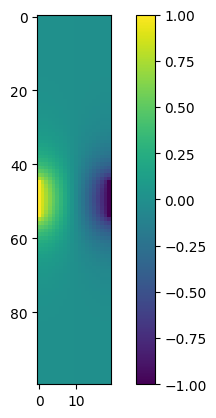

In [7]:
mask = np.zeros(sim_mesh.shape, dtype=int)
mask[:, 45:55, :1] = 1
mask[:, 45:55, -1:] = -1
mask[sim_mesh == 0] = 0

pos_electrode = np.argwhere(mask == 1)
neg_electrode = np.argwhere(mask == -1)

mesh = sim_mesh > 0

electrode = BipolarElectrode()
w, x = electrode.compute_weights(-K, mesh, pos_electrode, neg_electrode)

plt.figure()
plt.imshow(w[w.shape[0] // 2, :, :])
plt.colorbar()
plt.show()

# dx, dy, dz = np.gradient(w)

# vec_norm = np.sqrt(dx**2 + dy**2 + dz**2, )
# dx = np.divide(dx, vec_norm, out=np.zeros_like(dx), where=vec_norm!=0)
# dy = np.divide(dy, vec_norm, out=np.zeros_like(dy), where=vec_norm!=0)
# dz = np.divide(dz, vec_norm, out=np.zeros_like(dz), where=vec_norm!=0)

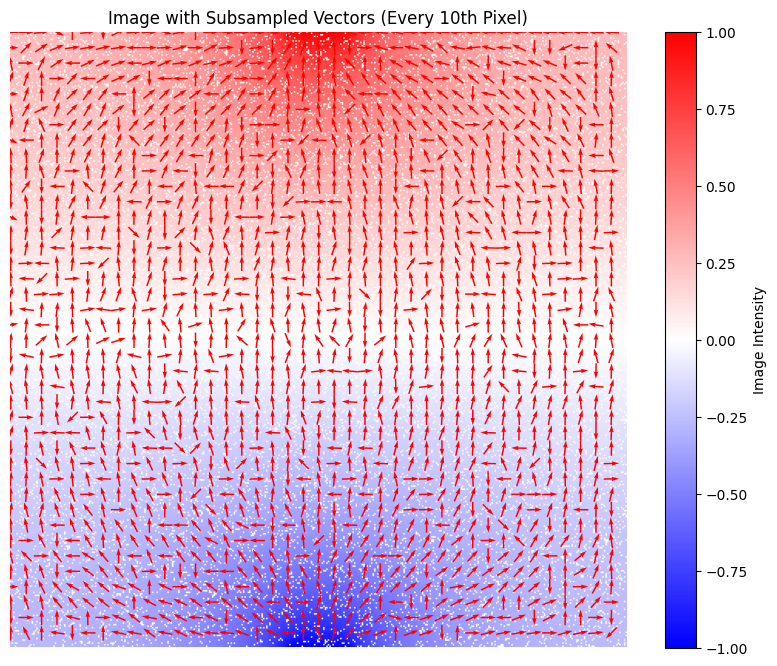

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- Example Data Setup (Replace with your arrays) ---
# m  -> 2D Image array of shape (H, W)
# dx -> Horizontal vector component of shape (H, W)
# dy -> Vertical vector component of shape (H, W)
H, W = w.shape

# 1. Create coordinate grids matching the image dimensions
X, Y = np.meshgrid(np.arange(W), np.arange(H))

# 2. Define the subsampling step (every 10th pixel)
step = 10

# 3. Slice all arrays using [::step, ::step]
X_sub  = X[::step, ::step]
Y_sub  = Y[::step, ::step]
dx_sub = 10*dy[::step, ::step]
dy_sub = 10*dx[::step, ::step]

%matplotlib inline
# --- Plotting ---
plt.figure(figsize=(10, 8))

# Display the background image
plt.imshow(w, cmap='bwr', origin='upper')
plt.colorbar(label="Image Intensity")
# Overlay the subsampled vectors
# Note: pivot='middle' centers the arrow on the grid point; scale adjusts arrow lengths
plt.quiver(X_sub, Y_sub, dx_sub, dy_sub, 
           color='red', 
           angles='xy', 
           scale_units='xy', 
           scale=1, 
           pivot='middle')

plt.title(f"Image with Subsampled Vectors (Every {step}th Pixel)")

plt.axis('off')
plt.show()